# Assignment: Customer Segmentation with K-Means

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#first importing pandas library and reading the dataset.

# 1. Load the Dataset
● Read th eCSV file into a pandas DataFrame.
● Check for missing values and datatypes.

In [2]:
df = pd.read_csv('C:\\Users\\BOLYTECH.COMPUTERS\\Desktop\\Pinkardudu\\Dataset\\Mall_Customers.csv')

# 2. Explore the Data
● Summary statistics:.describe()
● Visualize distributions of Age, Annual Income, and Spending Score.
● Optional:Visualize Gender vs Spending Score using a boxplot.

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
CustomerID                200 non-null int64
Gender                    200 non-null object
Age                       200 non-null int64
Annual Income (k$)        200 non-null int64
Spending Score (1-100)    200 non-null int64
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# checking for missing values

df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
# Summary Statistics
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


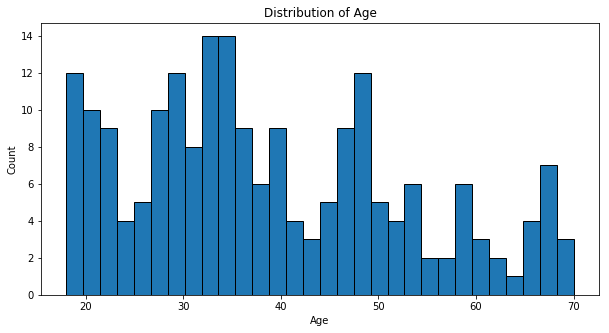

In [8]:
# Visualize distributions of Age, Annual Income, and Spending Score.
# Histogram for Age
plt.figure(figsize=(10,5))
plt.hist(df['Age'], bins=30,edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

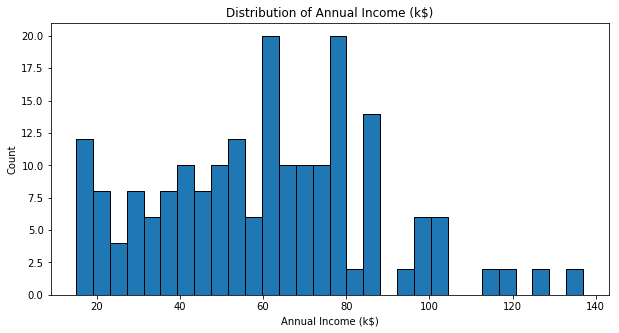

In [9]:
# Histogram for Annual Income (k$)
plt.figure(figsize=(10,5))
plt.hist(df['Annual Income (k$)'], bins=30,edgecolor='black')
plt.title('Distribution of Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Count')
plt.show()

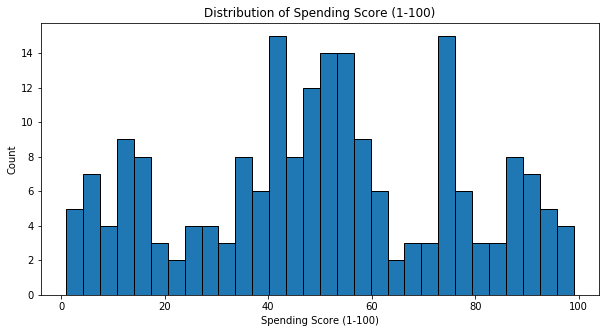

In [10]:
# Histogram for Spending Score (1-100)
plt.figure(figsize=(10,5))
plt.hist(df['Spending Score (1-100)'], bins=30,edgecolor='black')
plt.title('Distribution of Spending Score (1-100)')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Count')
plt.show()

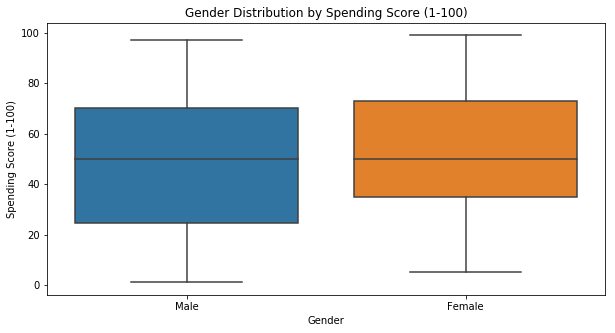

In [11]:
# ● Optional:Visualize Gende vs Spending Score using a boxplot.
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Gender', y='Spending Score (1-100)')
plt.title('Gender Distribution by Spending Score (1-100)')
plt.xlabel('Gender')
plt.ylabel('Spending Score (1-100)')
plt.show()

# 3. Select Features for Clustering
● Start simple:Annual Income(k$) and SpendingScore(1-100)

In [12]:
clustering_features = df[['Annual Income (k$)', 'Spending Score (1-100)']]
clustering_features.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# 4. Determine the Optimal Number of Clusters
● Use the Elbow Method and Silhouette Score

In [13]:
# Testing different numbers of clusters

k_range = range(2, 11)
empty_inertias = []

for k in k_range:
    # Create KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Fit the model
    kmeans.fit(clustering_features)

    # Store the inertia (within-cluster sum of squares)
    empty_inertias.append(kmeans.inertia_)

    print(f"k={k}: Inertia = {kmeans.inertia_:.2f}")

k=2: Inertia = 181363.60
k=3: Inertia = 106348.37
k=4: Inertia = 73679.79
k=5: Inertia = 44448.46
k=6: Inertia = 37233.81
k=7: Inertia = 30259.66
k=8: Inertia = 25011.84
k=9: Inertia = 21850.17
k=10: Inertia = 19672.07


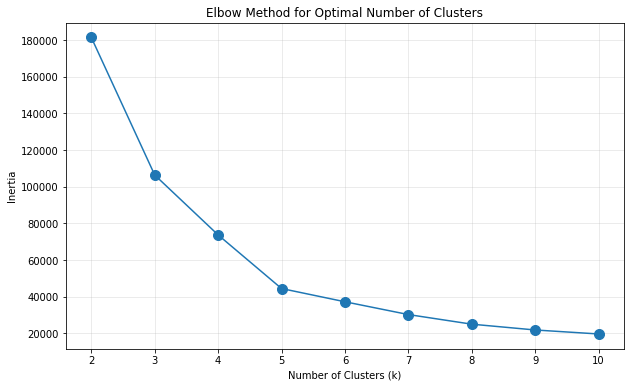

In [14]:
# Plotting the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, empty_inertias, 'o-', markersize=10)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Silhouette Score
silhouette_scores = []

for k in k_range:
    # Create and fit KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(clustering_features)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(clustering_features, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}")

k=2: Silhouette Score = 0.297
k=3: Silhouette Score = 0.468
k=4: Silhouette Score = 0.493
k=5: Silhouette Score = 0.554
k=6: Silhouette Score = 0.540
k=7: Silhouette Score = 0.526
k=8: Silhouette Score = 0.458
k=9: Silhouette Score = 0.457
k=10: Silhouette Score = 0.459


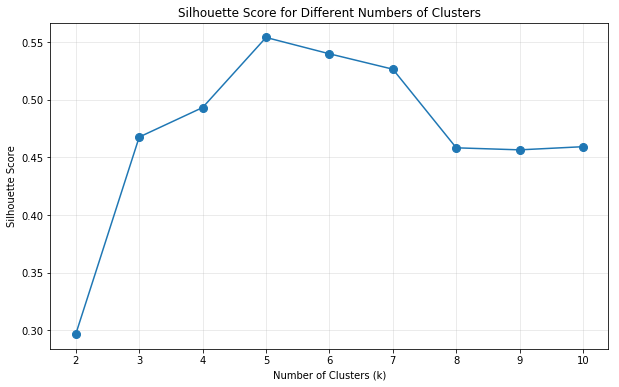

In [16]:
# Plotting silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'o-', markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Numbers of Clusters')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Build the K-Means Model
● Pick the optimal number of clusters.
● Fit K-Means and assign cluster labels.

In [17]:
# Pick the optimal number of clusters.
# Adding cluster labels to original dataframe
df_clustered = df.copy()
df_clustered['predicted_cluster'] = cluster_labels

df_clustered["predicted_cluster"].unique()

array([8, 7, 3, 0, 5, 4, 1, 9, 2, 6], dtype=int64)

In [18]:
# Fit K-Means and assign cluster labels.
# Create the final model
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit the model and get cluster labels
cluster_labels = final_kmeans.fit_predict(clustering_features)

cluster_labels[:10]

array([0, 3, 0, 3, 0, 3, 0, 3, 0, 3])

In [19]:
df_clustered.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),predicted_cluster
0,1,Male,19,15,39,8
1,2,Male,21,15,81,7
2,3,Female,20,16,6,3
3,4,Female,23,16,77,7
4,5,Female,31,17,40,8


# 6. Visualize the Clusters

In [20]:
# To visulize you must analyze the clusters
# Cluster distribution

cluster_counts = pd.Series(cluster_labels).value_counts()
print(cluster_counts)

3    100
1     39
2     38
0     23
dtype: int64


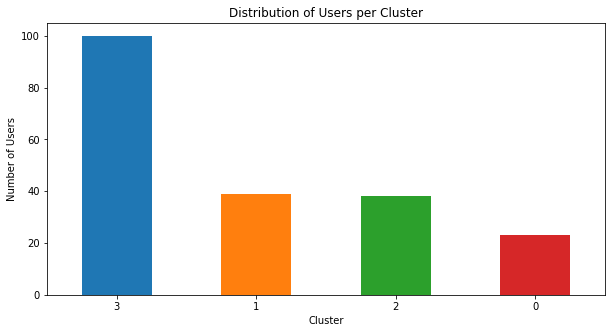

In [21]:
plt.figure(figsize=(10, 5))
cluster_counts.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.title('Distribution of Users per Cluster')
plt.xticks(rotation=0)
plt.show()

# In summary
The above data analysis shows
1. The Attributes and Elements of the all the Cluster.
2. Well labeled cluster with meaning evaluation.
3. well organized and structured cluster.